# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import os, pathlib, subprocess, sys
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
TARGET = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
TARGET.parent.mkdir(parents=True, exist_ok=True)
if not TARGET.exists():
    print('Downloading the course resources...')
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
else:
    print('Using the existing course folder; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 07</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Consultas, llaves y valores (Q, K y V)</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/07_queries_keys_y_values_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Por qué la atención separa consultas, llaves y valores en lugar de usar una sola representación?

En el notebook anterior estudiamos atención como una mezcla ponderada: pesos más valores producen una nueva representación. Quedaba abierta la pregunta más importante: ¿de dónde salen esos pesos?

Este notebook introduce tres roles diferentes para una misma posición de la secuencia. La consulta expresa qué se está buscando, la llave expresa contra qué se compara y el valor aporta el contenido que finalmente se mezcla. Esta separación es una decisión central del Transformer: `Q` y `K` calculan compatibilidad; `V` transporta la información que llega a la salida.

## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Explicar la diferencia funcional entre $Q$, $K$ y $V$ en una capa de atención.
2. Calcular puntajes de atención mediante producto punto escalado y transformarlos en pesos con softmax.
3. Interpretar una fila de atención como distribución sobre posiciones consultadas.
4. Verificar con tensores que $V$ se mezcla después de calcular los pesos, mientras $Q$ y $K$ participan en la comparación.
5. Reconocer el límite interpretativo: un peso alto indica contribución bajo una proyección concreta, no una explicación semántica completa.


## Marco conceptual

La atención requiere dos operaciones distintas. Primero, cada posición debe decidir qué otras posiciones son relevantes. Segundo, debe mezclar contenido procedente de esas posiciones. Si usáramos una sola representación para todo, comparación y contenido quedarían atados al mismo espacio. El Transformer separa esos papeles mediante tres proyecciones aprendibles.

- **Consulta $q_t$:** representación de lo que la posición $t$ usa para comparar.
- **Llave $k_j$:** representación de la posición $j$ usada como referencia de comparación.
- **Valor $v_j$:** contenido de la posición $j$ que se mezcla si recibe peso.

La intuición es: una consulta se compara contra varias llaves; esa comparación produce logits o puntajes; softmax convierte esos puntajes en pesos; los pesos mezclan valores.

En self-attention, $Q$, $K$ y $V$ nacen del mismo tensor de entrada $X$, pero mediante matrices distintas: $W_Q$, $W_K$ y $W_V$. Por eso pueden tener la misma forma y, aun así, cumplir roles diferentes.

Esta separación evita un error conceptual frecuente: $K$ y $V$ pueden tener la misma forma tensorial, pero no cumplen el mismo papel. Las llaves participan en la decisión de relevancia; los valores aportan la información que fluye hacia la salida.

## Idea visual: consultas, llaves y valores

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/07_queries_keys_y_values.png" alt="Consultas, llaves y valores" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La figura debe leerse como un mapa de roles, no como una prueba matemática. La consulta de una posición se compara con llaves; de esa comparación salen pesos; esos pesos se aplican sobre valores. El flujo importante es:

$$
QK^\top \rightarrow \operatorname{softmax} \rightarrow \text{pesos} \rightarrow V.
$$

La lectura crítica es que relevancia y contenido no son el mismo objeto: `Q` y `K` producen la distribución de atención, mientras `V` aporta lo que se combina en la salida.

## Formulación matemática

Sea $x_t \in \mathbb{R}^{C}$ la representación de entrada de la posición $t$. A partir de $x_t$ se calculan tres proyecciones lineales:

$$
q_t = x_t W_Q,
\qquad
k_t = x_t W_K,
\qquad
v_t = x_t W_V.
$$

Esta ecuación se lee así: el mismo vector de entrada se transforma en tres vectores con roles distintos. Las matrices $W_Q$, $W_K$ y $W_V$ son parámetros aprendibles.

Para medir qué tanto la posición $t$ atiende a la posición $j$, se calcula un puntaje por producto punto escalado. Aquí $d_k$ denota la dimensión de las llaves; en el experimento de este notebook coincide con la dimensión proyectada $D$.

$$
s_{tj} = \frac{q_t k_j^\top}{\sqrt{d_k}}.
$$

Esta ecuación se lee así: la consulta de la posición $t$ se compara con la llave de la posición $j$; el resultado se divide por $\sqrt{d_k}$ para controlar la escala de los puntajes cuando la dimensión crece. El valor $v_j$ todavía no participa en este cálculo.

Luego los puntajes de una fila se normalizan con softmax:

$$
\alpha_{tj} = \frac{\exp(s_{tj})}{\sum_{r=1}^{T} \exp(s_{tr})}.
$$

Esta ecuación se lee así: para una posición fija $t$, cada peso $\alpha_{tj}$ indica cuánto contribuirá la posición $j$ a la salida de $t$.

Finalmente, la salida de la posición $t$ es una mezcla de valores:

$$
y_t = \sum_{j=1}^{T} \alpha_{tj} v_j.
$$

Esta ecuación se lee así: una vez calculados los pesos, la salida ya no mezcla llaves sino valores. Las llaves ayudaron a decidir los pesos; los valores transportan el contenido.

## Traducción tensorial

Para un batch con $B$ secuencias, $T$ posiciones y dimensión proyectada $D$, los objetos principales tienen forma:

$$
X \in \mathbb{R}^{B \times T \times C},
\qquad
Q,K,V \in \mathbb{R}^{B \times T \times D}.
$$

La matriz de puntajes para cada elemento del batch tiene esta forma. La transposición de $K$ se entiende sobre los dos últimos ejes, no sobre el eje de batch:

$$
S = \frac{QK^\top}{\sqrt{D}},
\qquad
S \in \mathbb{R}^{B \times T \times T}.
$$

Esta ecuación se lee así: cada fila de $S$ compara una consulta contra todas las llaves de la secuencia.

La salida de atención conserva el eje de posiciones y la dimensión de valores:

$$
A = \operatorname{softmax}(S),
\qquad
Y = AV,
\qquad
Y \in \mathbb{R}^{B \times T \times D}.
$$

Esta ecuación se lee así: los pesos se aplican sobre valores, no sobre llaves. $A$ no contiene contenido textual; contiene pesos. El contenido que fluye hacia $Y$ viene de $V$.

## Preparación del entorno


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

warnings.filterwarnings("ignore", message="Pandas requires version.*")

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.atencion_experimentos as atencion_experimentos
import fundamentos_transformers.componentes_interactivos as componentes_interactivos
import fundamentos_transformers.visualizacion as visualizacion

atencion_experimentos = importlib.reload(atencion_experimentos)
componentes_interactivos = importlib.reload(componentes_interactivos)
visualizacion = importlib.reload(visualizacion)

crear_explorador_qkv_atencion = componentes_interactivos.crear_explorador_qkv_atencion
configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento mínimo

Construiremos una secuencia artificial con tres posiciones y cuatro canales. Después aplicaremos tres proyecciones lineales para obtener $Q$, $K$ y $V$. El experimento se concentrará en una fila de atención: la posición $t=1$.

La pregunta experimental es: ¿qué posiciones reciben más peso cuando $q_1$ se compara contra todas las llaves, y cómo esos pesos mezclan los valores $v_j$?

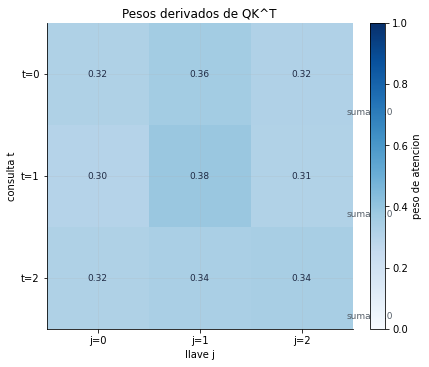

In [2]:
resultado_qkv = atencion_experimentos.preparar_experimento_qkv(seed=7)

mostrar_tablas_en_columnas(
    [
        ("Auditoría de formas", resultado_qkv.auditoria),
        ("Fila de atención t=1", resultado_qkv.fila_atencion),
        ("Verificación numérica", resultado_qkv.verificacion),
        ("Separación de roles", resultado_qkv.roles),
    ],
    min_width="380px",
)


Las tablas fuerzan la lectura completa de una fila de atención. Primero, $Q$ y $K$ producen `scores` con forma $(B,T,T)$. Después softmax convierte cada fila en una distribución. Solo entonces aparece $V$: los pesos de la fila $t=1$ se multiplican por los valores para producir la salida de esa posición.

La verificación `alpha_t @ V == out[0,t]` es la evidencia central del notebook: reconstruye una salida desde una fila de pesos y muestra que mezclar llaves sería un cálculo distinto al de atención.

## Visualización de pesos

La matriz de calor muestra $A \in \mathbb{R}^{T \times T}$. Las filas corresponden a posiciones que consultan; las columnas corresponden a llaves consultadas. Cada fila suma uno porque softmax se aplica sobre las columnas de esa fila.

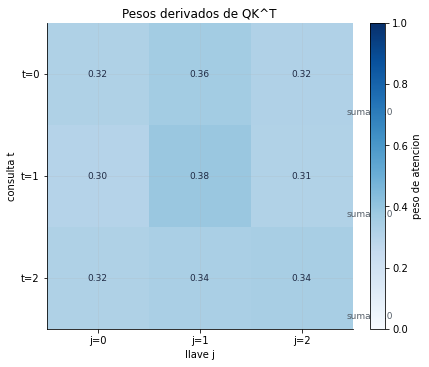

In [3]:
display(resultado_qkv.figura)
plt.close(resultado_qkv.figura)


El mapa no debe interpretarse como una explicación semántica completa. Solo muestra la distribución de pesos inducida por las proyecciones actuales. Como las proyecciones están inicializadas al azar, los pesos sirven para estudiar el mecanismo, no para inferir relaciones lingüísticas reales.

La lectura importante es operacional: cada fila se obtuvo comparando una consulta contra todas las llaves, y esa fila se aplicará sobre los valores.

## Explorador interactivo

El explorador permite seleccionar la posición de consulta $t$. Para cada $t$, muestra la consulta $q_t$, los puntajes contra cada llave, los pesos de softmax y la mezcla de valores. También incluye un control conceptual: qué vector saldría si se mezclaran llaves en lugar de valores.

Ese control no es la salida correcta de atención; sirve para hacer visible la separación de roles.

In [4]:
crear_explorador_qkv_atencion()


## Verificación de aprendizaje

Usa el explorador y responde con evidencia:

1. Selecciona dos posiciones de consulta distintas. ¿Cambian los puntajes y los pesos? Cita al menos dos pesos.
2. Explica por qué $q_t$ se compara con $K$, pero la salida se construye con $V$.
3. Reconstruye una fila: toma los pesos $\alpha_{tj}$ de una consulta y explica cómo producirían $y_t$ al mezclarse con los valores.
4. Observa el control conceptual del explorador. ¿Por qué mezclar llaves no representa la salida correcta de atención?
5. Indica qué forma tendría la matriz de pesos si la secuencia tuviera $T=8$ posiciones.

La respuesta debe distinguir forma tensorial, rol matemático y lectura computacional.

## Análisis crítico

Lo observado puede leerse en tres niveles:

1. **Qué ocurrió:** las proyecciones generaron $Q$, $K$ y $V$; $QK^\top$ produjo puntajes; softmax produjo pesos; los pesos mezclaron valores.
2. **Por qué ocurrió:** separar proyecciones permite que la comparación y el contenido se representen en espacios funcionalmente distintos.
3. **Qué límite tiene la conclusión:** en este experimento las proyecciones no están entrenadas. Por tanto, los pesos no deben leerse como evidencia de comprensión, relevancia lingüística real o explicación definitiva.

El valor formativo está en entender el mecanismo antes de usarlo dentro de modelos más grandes. La tabla de formas y la reconstrucción de una fila son herramientas de depuración: si una implementación falla, conviene revisar primero qué eje representa consultas, qué eje representa llaves y dónde entra $V$.

## Síntesis

La cadena operacional del notebook es:

$$
X \rightarrow Q,K,V \rightarrow QK^\top/\sqrt{D} \rightarrow A=\operatorname{softmax}(S) \rightarrow Y=AV.
$$

Esta cadena se lee así: la entrada se proyecta en consultas, llaves y valores; consultas y llaves producen pesos; los pesos mezclan valores para construir la salida.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que Q y K deciden la distribución de atención, mientras V aporta el contenido que realmente se combina en la salida.
</div>

## Preguntas de discusión

1. ¿Por qué $Q$ y $K$ pueden tener la misma forma pero no el mismo significado funcional?
2. ¿Qué papel cumple el factor $\sqrt{D}$ en el producto punto escalado?
3. ¿Qué evidencia experimental muestra que $V$ entra después del cálculo de pesos?
4. ¿Por qué una matriz de atención inicializada al azar no debe interpretarse semánticamente?
5. ¿Qué cambia cuando estas operaciones se vectorizan y se aplican simultáneamente a todas las posiciones?


## Continuidad

El siguiente notebook llevará esta operación a una forma más matricial y vectorizada. En lugar de estudiar una fila de atención de manera aislada, veremos cómo todas las posiciones producen sus pesos y salidas simultáneamente, preparando el camino hacia self-attention completa.
